# ARTI406 – Assignment 1: Exploratory Data Analysis (EDA)
## Dataset: Chocolate Sales
**Source:** Kaggle – Chocolate Sales Dataset  
**Student analysis using Python (pandas, matplotlib, seaborn)**

---
EDA is the first and most important step in any Machine Learning project. Before building models, we must understand:
- What does the data represent?
- Are there missing values or duplicates?
- What patterns and trends exist?
- Which variables influence each other?

## Step 1 – Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("Libraries imported successfully.")

## Step 2 – Load Dataset

In [ ]:
df = pd.read_csv('Chocolate_Sales_2.csv')
print("Shape (rows, columns):", df.shape)
df.head()

### Dataset Overview
The raw dataset contains **3,284 rows** and **6 columns**:

| Column | Type | Description |
|---|---|---|
| Sales Person | String | Name of the sales representative |
| Country | String | Country where the sale occurred |
| Product | String | Chocolate product name |
| Date | String | Date of the transaction (DD-MM-YYYY) |
| Amount | String | Sale value in USD (needs cleaning) |
| Boxes Shipped | Integer | Number of boxes shipped per transaction |

## Step 3 – Basic Data Exploration

In [ ]:
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values per Column:")
print(df.isnull().sum())
print()
print("Duplicate Rows:", df.duplicated().sum())
print()
print("Statistical Summary:")
df.describe()

## Step 4 – Data Cleaning

### Issues Identified
After initial inspection, the following issues were found:

| Issue | Count | Action Taken |
|---|---|---|
| Duplicate rows | 1 | Removed |
| Missing values in 'Country' | 1 | Removed |
| 'Amount' stored as string (e.g., `$5,320.00`) | All rows | Converted to float |
| 'Date' stored as string (DD-MM-YYYY) | All rows | Parsed to datetime |

### Why cleaning was needed
- **Duplicates** can skew aggregations and statistics.
- **Missing Country** values prevent correct geographical analysis.
- **Amount as string** cannot be used in math/aggregation without conversion.
- **Date as string** prevents time-series analysis (sorting, grouping by month/year).

In [ ]:
# --- BEFORE CLEANING ---
print("BEFORE CLEANING")
print("Rows:", len(df))
print("Missing values:"); print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Amount dtype:", df['Amount'].dtype, "| Sample:", df['Amount'][0])
print("Date sample:", df['Date'][0])

In [ ]:
# --- CLEANING STEPS ---

# 1. Remove duplicate rows
df_clean = df.drop_duplicates()

# 2. Remove rows where Country is missing
df_clean = df_clean.dropna(subset=['Country'])

# 3. Convert Amount from string "$5,320.00" → float
df_clean = df_clean.copy()
df_clean['Amount'] = df_clean['Amount'].str.replace('[$,]', '', regex=True).astype(float)

# 4. Parse Date to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

# 5. Add helper columns for time analysis
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
df_clean['Year'] = df_clean['Date'].dt.year

print("AFTER CLEANING")
print("Rows:", len(df_clean))
print("Missing values:"); print(df_clean.isnull().sum())
print("Duplicates:", df_clean.duplicated().sum())
print("Amount dtype:", df_clean['Amount'].dtype, "| Sample:", df_clean['Amount'].iloc[0])
print("Date dtype:", df_clean['Date'].dtype, "| Sample:", df_clean['Date'].iloc[0])

In [ ]:
# Summary statistics after cleaning
print("\n=== Summary Statistics After Cleaning ===")
print(f"Total transactions: {len(df_clean):,}")
print(f"Total Revenue:      ${df_clean['Amount'].sum():,.2f}")
print(f"Average Sale:       ${df_clean['Amount'].mean():,.2f}")
print(f"Min Sale:           ${df_clean['Amount'].min():,.2f}")
print(f"Max Sale:           ${df_clean['Amount'].max():,.2f}")
print(f"Date Range:         {df_clean['Date'].min().date()} to {df_clean['Date'].max().date()}")
print(f"Unique Sales Reps:  {df_clean['Sales Person'].nunique()}")
print(f"Unique Products:    {df_clean['Product'].nunique()}")
print(f"Countries:          {sorted(df_clean['Country'].unique().tolist())}")

## Step 5 – Visualizations & Insights

We use **10 visualizations** to explore different aspects of the chocolate sales dataset.
Each chart is chosen to reveal a specific insight about the data.

### Plot 1 – Total Sales by Country (Bar Chart)
**Why this visualization?** Bar charts are ideal for comparing totals across a limited set of categories. Here we compare sales revenue across 6 countries.

**Insight:** Australia and the UK lead in total revenue. India, Canada, New Zealand, and USA show lower but comparable figures.

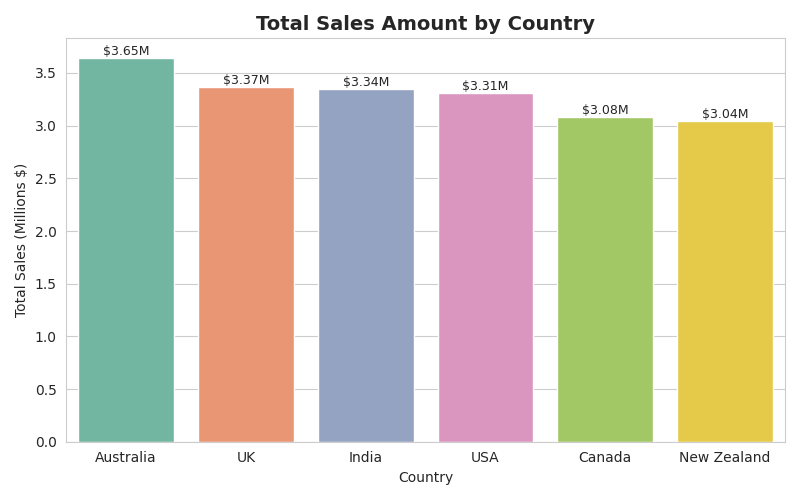

In [ ]:
country_sales = df_clean.groupby('Country')['Amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=country_sales.index, y=country_sales.values/1e6, palette='Set2', ax=ax)
ax.set_title('Total Sales Amount by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Total Sales (Millions $)')
for bar in ax.patches:
    ax.annotate(f'${bar.get_height():.2f}M', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 2 – Monthly Sales Trend (Line Chart)
**Why this visualization?** Line charts reveal time-based patterns and seasonality.

**Insight:** Sales show fluctuation over months with some spikes. The trend helps identify seasonal peaks useful for forecasting.

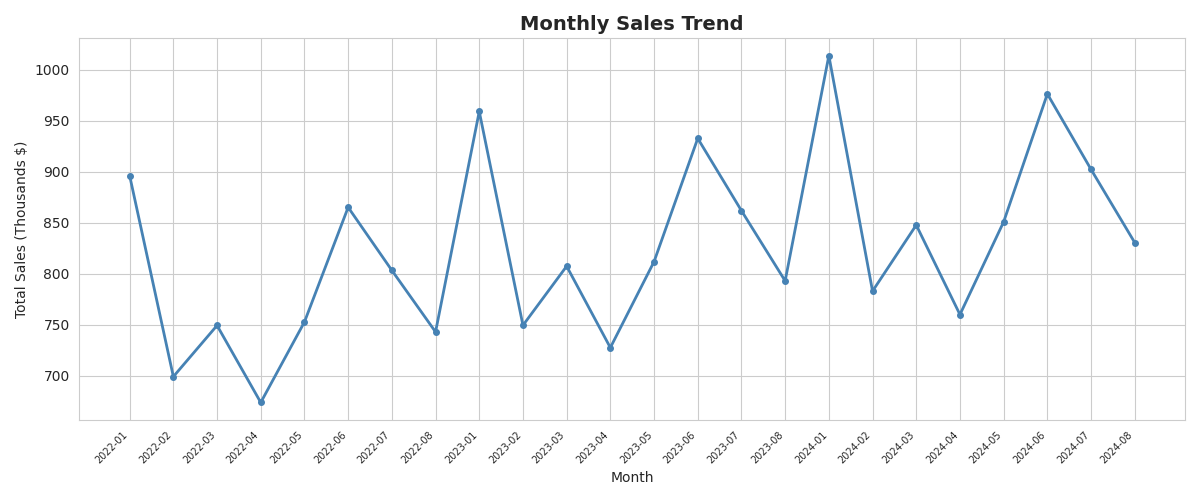

In [ ]:
monthly = df_clean.groupby('Month')['Amount'].sum()
monthly.index = monthly.index.astype(str)
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly.index, monthly.values/1e3, marker='o', linewidth=2, color='steelblue', markersize=4)
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales (Thousands $)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

### Plot 3 – Top 10 Products by Revenue (Horizontal Bar Chart)
**Why this visualization?** Horizontal bars work well when category names are long.

**Insight:** A small set of products like "Smooth Silky Salty" and "50% Dark Bites" drive a disproportionate share of revenue — classic Pareto effect.

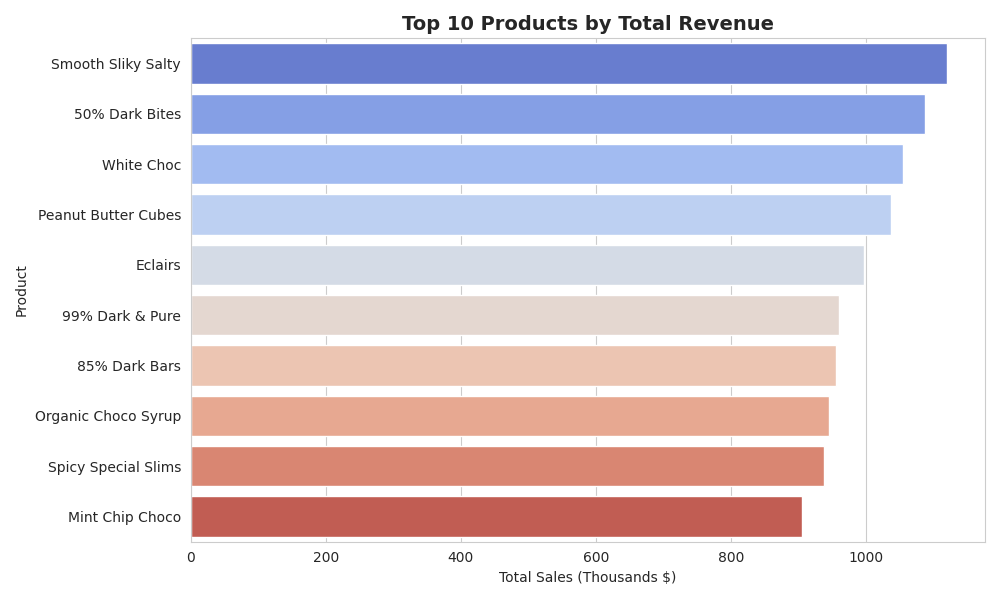

In [ ]:
product_sales = df_clean.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(y=product_sales.index, x=product_sales.values/1e3, palette='coolwarm', ax=ax)
ax.set_title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (Thousands $)'); ax.set_ylabel('Product')
plt.tight_layout()
plt.show()

### Plot 4 – Top 10 Sales Persons by Revenue (Horizontal Bar Chart)
**Why this visualization?** Highlights top performers — useful for HR and incentive planning.

**Insight:** Performance varies significantly between sales reps, suggesting differences in territory, product mix, or individual effectiveness.

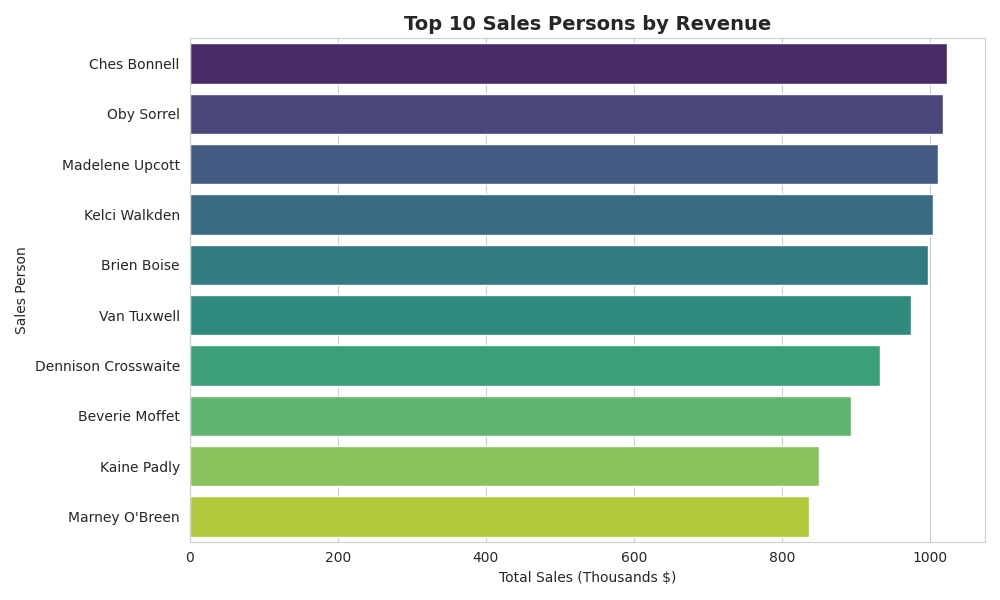

In [ ]:
sp_sales = df_clean.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(y=sp_sales.index, x=sp_sales.values/1e3, palette='viridis', ax=ax)
ax.set_title('Top 10 Sales Persons by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (Thousands $)'); ax.set_ylabel('Sales Person')
plt.tight_layout()
plt.show()

### Plot 5 – Distribution of Sale Amounts (Histogram)
**Why this visualization?** Histograms reveal the shape of a numerical distribution — skewness, outliers, and concentration.

**Insight:** Most transactions are clustered at lower amounts (right-skewed), meaning occasional large orders inflate the average. This is important when deciding whether to use mean or median as a performance metric.

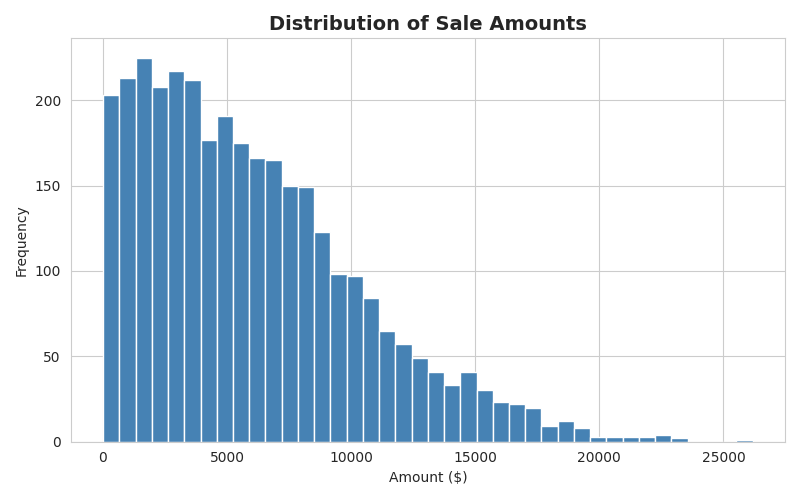

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_clean['Amount'], bins=40, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Sale Amounts', fontsize=14, fontweight='bold')
ax.set_xlabel('Amount ($)'); ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Plot 6 – Boxes Shipped by Country (Box Plot)
**Why this visualization?** Box plots show the spread, median, and outliers of a numeric variable across categories.

**Insight:** Most countries have similar median shipment sizes, but Australia and Canada show more high-end outliers — implying occasional bulk orders.

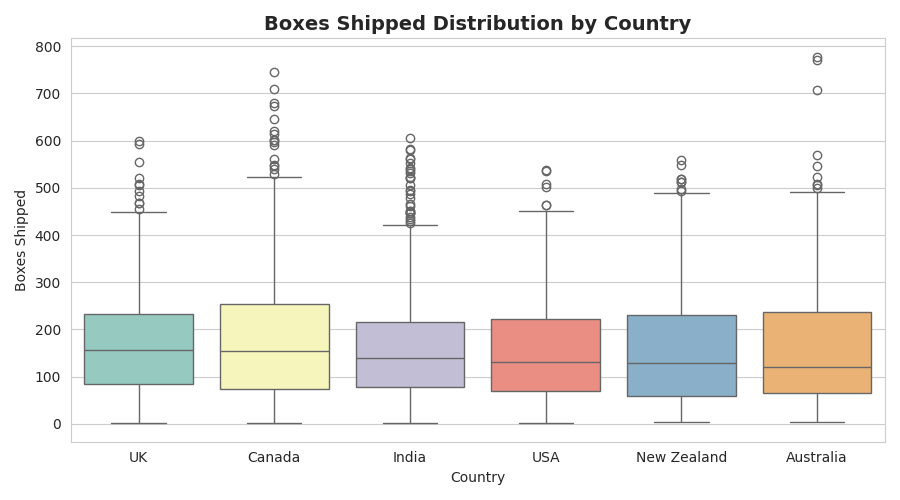

In [ ]:
country_order = df_clean.groupby('Country')['Boxes Shipped'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df_clean, x='Country', y='Boxes Shipped', order=country_order, palette='Set3', ax=ax)
ax.set_title('Boxes Shipped Distribution by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Boxes Shipped')
plt.tight_layout()
plt.show()

### Plot 7 – Average Sale Amount by Country & Year (Heatmap)
**Why this visualization?** Heatmaps show two-dimensional relationships using color intensity.

**Insight:** Average sale amounts differ by both country and year. Some regions show notable growth or decline over the 2022–2024 period.

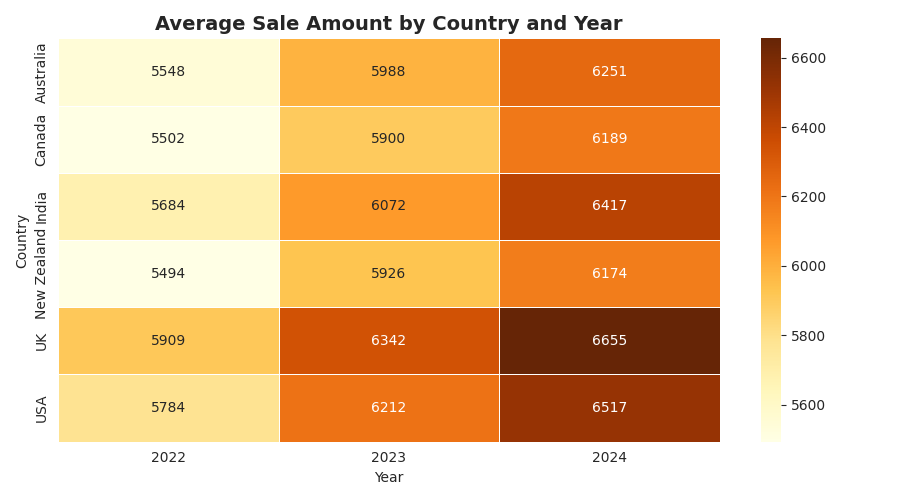

In [ ]:
pivot = df_clean.pivot_table(values='Amount', index='Country', columns='Year', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrBr', linewidths=0.5, ax=ax)
ax.set_title('Average Sale Amount by Country and Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 8 – Sales Share by Country (Pie Chart)
**Why this visualization?** Pie charts illustrate proportional contribution of each category to the whole.

**Insight:** No single country dominates entirely, but the top 2–3 markets together account for over half of total sales.

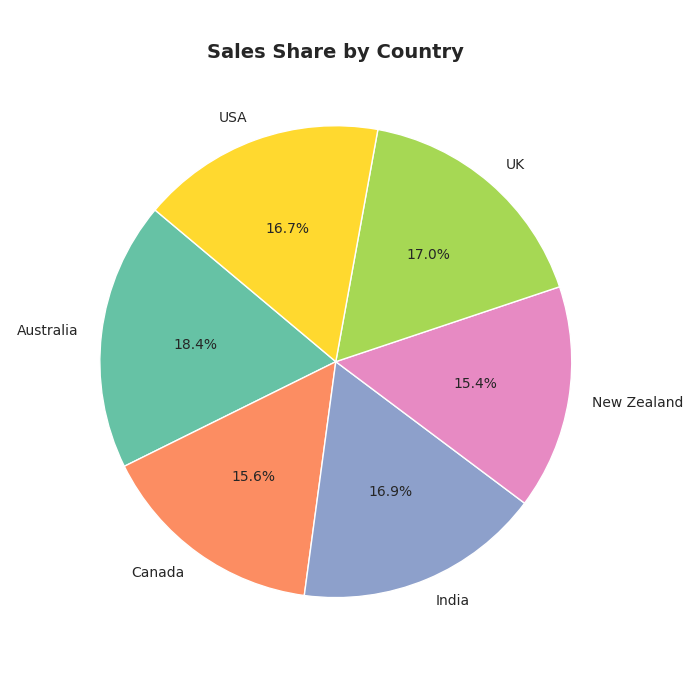

In [ ]:
country_pct = df_clean.groupby('Country')['Amount'].sum()
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(country_pct, labels=country_pct.index, autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('Set2'))
ax.set_title('Sales Share by Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 9 – Boxes Shipped vs Sale Amount (Scatter Plot)
**Why this visualization?** Scatter plots reveal the relationship (or lack thereof) between two numeric variables.

**Insight:** There is a weak positive correlation between boxes shipped and amount — more boxes generally means more revenue, but the relationship has wide variation, suggesting pricing differences by product or discount structures.

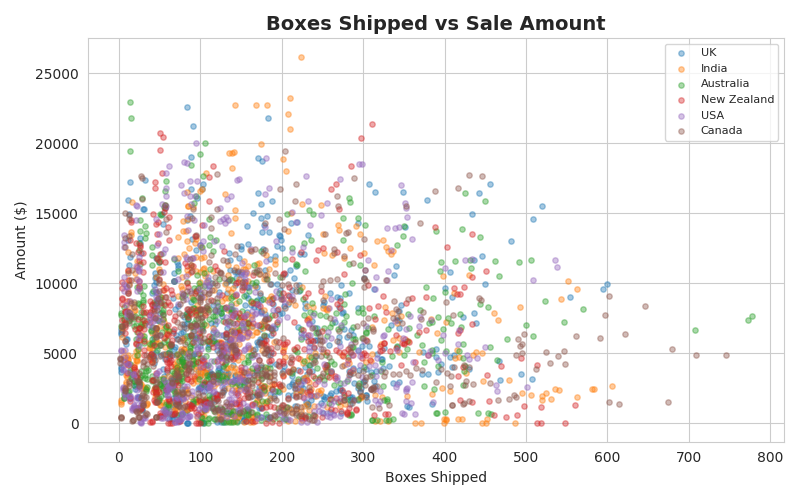

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
for country in df_clean['Country'].unique():
    sub = df_clean[df_clean['Country'] == country]
    ax.scatter(sub['Boxes Shipped'], sub['Amount'], label=country, alpha=0.4, s=15)
ax.set_title('Boxes Shipped vs Sale Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Boxes Shipped'); ax.set_ylabel('Amount ($)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Plot 10 – Total Sales by Year (Bar Chart)
**Why this visualization?** Year-level bar comparison summarizes macro performance.

**Insight:** 2022 and 2023 show strong full-year sales. 2024 data ends in August, so the lower bar reflects a partial year, not a business decline.

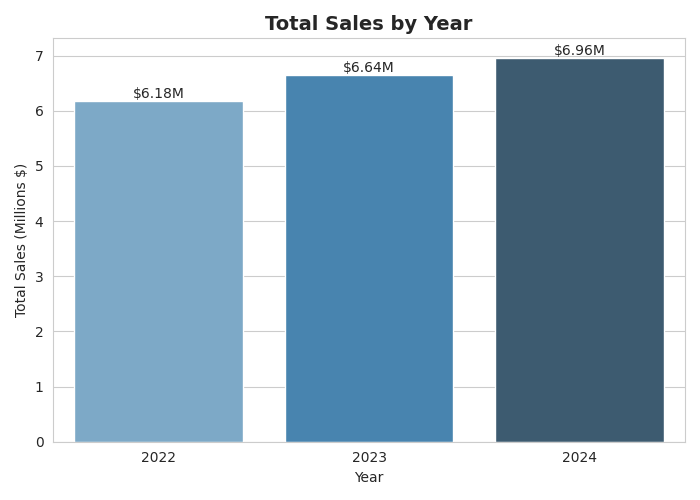

In [ ]:
yearly = df_clean.groupby('Year')['Amount'].sum()
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=yearly.index.astype(str), y=yearly.values/1e6, palette='Blues_d', ax=ax)
ax.set_title('Total Sales by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Total Sales (Millions $)')
for bar in ax.patches:
    ax.annotate(f'${bar.get_height():.2f}M', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Step 6 – Summary of Key Findings

| Finding | Detail |
|---|---|
| **Top Markets** | Australia and UK generate the highest total revenue |
| **Best Products** | A handful of products (Smooth Silky Salty, 50% Dark Bites) drive most revenue |
| **Sales Rep Performance** | Wide variation — top performers drive significantly more revenue |
| **Sale Amount Distribution** | Right-skewed — most deals are small; a few large deals inflate the mean |
| **Boxes vs Amount** | Weak positive correlation — volume doesn't perfectly predict revenue |
| **Yearly Trend** | 2022–2023 comparable; 2024 is a partial year |
| **Seasonality** | Monthly trend shows fluctuation useful for demand forecasting |

These insights can guide decisions in:
- **Marketing**: Focus on top markets and promote high-revenue products
- **HR/Incentives**: Identify and reward top-performing sales reps
- **Logistics**: Plan box shipments based on country demand patterns
- **ML Readiness**: Data is now clean, typed, and ready for predictive modeling